# Extended Data Figure 6

Reduction in keypoint tracking jitter from Facemap to Cheese3D by facial region.

Before running this notebook, make sure you have:
- `anipose-projects/20230919_long-anes-clips_rig2`

And the Facemap results:
- `facemap-projects/20240919_long-anes-clips_rig2`

In [1]:
%load_ext autoreload
%autoreload 2

# Update path as if notebook was run from top-level repo directory
import os
import sys

pwd = %pwd
if pwd.endswith('notebooks'):
    sys.path.insert(0, os.path.abspath('..'))
    new_pwd = os.path.abspath(f"{pwd}/..")
    %cd {new_pwd}

/data/disk2/irenenozal/mouse-fe-analysis


/home/irenenozal/micromamba/envs/mouse-fe-analysis/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy as sp
import kneed
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pickle
from pathlib import Path
from functools import reduce

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import GridSearchCV

from labutils.utils import maybe

# from fepipeline.features.landmarks import read_2d_data
from fepipeline.features.landmarks import read_3d_data

from fepipeline.anatomy import compute_measurements_df
from fepipeline.anatomy import (compute_mouth_area,
                                compute_euclidean_dist,
                                compute_eye_orbital_tightness,
                                compute_proptosis)
from labutils.plotting import (sns_setup,
                               landmark_cmap,
                               measurements_cmap,
                               plot_data_grid,
                               plot_trialized_helper,
                               save_figure)
from scipy.stats import pearsonr, ttest_rel, wilcoxon
from scipy.signal import convolve

sns_setup()
OUTPUT_DIR = "./figures/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONTROL_CMAP = sns.color_palette([sns.color_palette("colorblind")[2],
                                  sns.color_palette("colorblind")[-3],
                                  sns.color_palette("colorblind")[3]])

STILL_PERIODS = { #Set to None because I am using the clips (time windows below only)
    "B6": (None,None), #(38.50, 44.05),
    "B8": (None,None), #(34.30, 39.55),
    "B15": (None,None), #(27.20, 34.15),
    "B20": (None,None), #(34.55, 41.00),
    "B26": (None,None), #(58.20, 63.28),
    # "B33": (44.30, 50.05)
}

REGION_ORDER = ["eye(left)", "eye(right)",
                "ear(left)", "ear(right)",
                "nose", "whisker pad", "mouth"]

_, LANDMARK_CMAP = landmark_cmap()
_, MEASUREMENT_CMAP = measurements_cmap()

ANIPOSE_BASE = "./anipose-projects/"
FACEMAP_BASE = './facemap-projects/'

# JITTER directories
JITTER_DIR = "20240919_long-anes-clips_rig2"
MICE_A = ["B6", "B8", "B15", "B20", "B26"]


datasets = ['c3d-pre-tri-2D', 'c3d-post-tri-2D', 'c3d-3D', 'facemap']


## 1. Define functions

In [3]:
# CHEESE3D (in 2D)
def read_2d_data(p, landmarks): #Modified from the read_2d_data function in fepipeline.features.landmarks
    dlc_df = pd.read_hdf(p)
    data_dict = {}
    root = dlc_df.keys()[0][0]
    for l in landmarks:
        try:
            dlc_df[root][l] #if the landmark name is for Facemap
        except KeyError:
            continue
        x_coord = dlc_df[root][l]['x'].values
        y_coord = dlc_df[root][l]['y'].values
        data_dict[l] = np.stack([x_coord, y_coord], 1)

    return data_dict

view_dict = {'R': ['nose(bottom)', 'nose(tip)', 'nose(top)', # nosebridge - facemap specific 
                   'pad(top)(right)', 'pad(side)(right)', 'pad(center)', 
                   'whisker(I)', 'whisker(II)', 'whisker(III)', # - facemap specific
                   'lowerlip', 'upperlip(right)', 'mouth', #mouth - facemap specific
                   'eye(front)(right)', 'eye(top)(right)', 'eye(back)(right)', 'eye(bottom)(right)', 
                   'eye(front)', 'eye(top)', 'eye(back)', 'eye(bottom)', # - facemap specific
                   'ear(base)(right)', 'ear(top)(right)', 'ear(tip)(right)', 'ear(bottom)(right)'],
             'L': ['nose(bottom)', 'nose(tip)', 'nose(top)', # nosebridge - facemap specific
                   'pad(top)(left)', 'pad(side)(left)', 'pad(center)', 
                   'lowerlip', 'upperlip(left)', 'mouth', #mouth - facemap specific
                   'eye(front)(left)', 'eye(top)(left)', 'eye(back)(left)', 'eye(bottom)(left)', 
                   'eye(front)', 'eye(top)', 'eye(back)', 'eye(bottom)', # - facemap specific
                   'ear(base)(left)', 'ear(top)(left)', 'ear(tip)(left)', 'ear(bottom)(left)'],
             'TR': ['nose(tip)', 'nose(top)', 'nose(bottom)', # nose(bottom), nosebridge - facemap specific 
                   'pad(top)(right)',
                   'mouth', 'lowerlip', # - facemap specific
                   'eye(front)(right)', 'eye(top)(right)', 'eye(back)(right)', 'eye(bottom)(right)', 
                   'eye(front)', 'eye(top)', 'eye(back)', 'eye(bottom)', # - facemap specific
                   'ear(base)(right)', 'ear(top)(right)', 'ear(tip)(right)', 'ear(bottom)(right)'],
             'TL': ['nose(tip)', 'nose(top)', 'nose(bottom)', # nose(bottom), nosebridge - facemap specific
                   'pad(top)(left)', 
                   'mouth', 'lowerlip', # - facemap specific
                   'eye(front)(left)', 'eye(top)(left)', 'eye(back)(left)', 'eye(bottom)(left)', 
                   'eye(front)', 'eye(top)', 'eye(back)', 'eye(bottom)', # - facemap specific
                   'ear(base)(left)', 'ear(top)(left)', 'ear(tip)(left)', 'ear(bottom)(left)'],
             'TC': ['nose(tip)', 'nose(top)',  # nosebridge - facemap specific 
                    'eye(front)', 'eye(top)', 'eye(back)', 'eye(bottom)', # - facemap specific (this is left eye)
                   'eye(front)(left)', 'eye(top)(left)', 'eye(back)(left)', 'eye(bottom)(left)', 
                   'eye(front)(right)', 'eye(top)(right)', 'eye(back)(right)', 'eye(bottom)(right)'],
             'BC': ['nose(bottom)', 'nose(tip)', 'nose(top)',  # nosebridge - facemap specific
                   'pad(top)(left)', 'pad(side)(left)', 'pad(center)', 
                   'pad(top)(right)', 'pad(side)(right)', 'pad(center)', 
                   'lowerlip', 'upperlip(left)', 'upperlip(right)', 'mouth']  #mouth - facemap specific
                   }


In [4]:
# Facemap function (adapted from their repo)
# Link: https://github.com/MouseLand/facemap/blob/main/facemap/utils.py
import h5py

def load_keypoints(bodyparts, h5_path, view):
    """Load keypoints using h5py

    Args:
        bodyparts (list): List of bodyparts in the same order as in FacemapDataset
        h5_path (hdf filepath): Path to hdf file containing keypoints
    Returns:
        pose_data (np.array): Array of size 3 x key points x frames
    """

    # pose_likelihood = []
    data_dict = {}
    pose_data = h5py.File(h5_path, "r")["Facemap"]

    for bodypart in bodyparts:  # Load bodyparts in the same order as in FacemapDataset
        try:
            pose_data[bodypart]
        except KeyError:
            continue # print(bodypart, ' does not exist in Facemap.')
        # else:      # print(bodypart, ' exists in Facemap.')
            
        # pose_likelihood.append(pose_data[bodypart]["likelihood"][:])
        x_coord = pose_data[bodypart]["x"][:]
        y_coord = pose_data[bodypart]["y"][:]
        bodypart_name = bodypart
        if 'eye' in bodypart:
            if view in ['L', 'TL', 'TC']:
                bodypart_name = bodypart + '(left)'
            else:
                bodypart_name = bodypart + '(right)'
        data_dict[bodypart_name] = np.stack([x_coord, y_coord], 1)

    # pose_likelihood = np.array([pose_likelihood])  # size: key points x frames

    return data_dict #pose_data

In [5]:
def z_score(raw_data):
    mean = np.mean(raw_data, 0, keepdims=True)
    sigma = np.std(raw_data, 0, keepdims=True) #1
    sigma[sigma == 0] = 1
    return (raw_data-mean)/sigma

In [6]:
def moving_avg_filter(signal, window = 3, stride = 1, truncate = True):
    kernel = np.ones(window) / window
    result = convolve(signal, kernel, mode="same")[window:-window]

    return result[::stride]

## 2. Load data

In [7]:
#Long-anes clips from year 2023 dataset: Load 2D and 3D data from Facemap and Cheese3D (pre, post-triangulation 2D & 3D)

COORDINATE_PATHS_FM = {}
COORDINATE_PATHS_C3D_PRE = {}
COORDINATE_PATHS_C3D_POST = {}
COORDINATE_PATHS_C3D_3D = {}
key_cols = ('mouse', 'source', 'condition', 'dataset', 'view')
models = [ANIPOSE_BASE, FACEMAP_BASE]
for m in models:
    source = 'rig2'
    if m == FACEMAP_BASE:
        for p in Path(m).glob(f'{JITTER_DIR}/*/*.h5'):
            mouse = p.name.split('_')[2]
            view = p.name.split('_')[6]
            COORDINATE_PATHS_FM[(mouse, source, 'anes', 'facemap', view)] = p
    else: 
        for mo in MICE_A:
            folder1 = f'*{mo}*/pose-2d' #Pre-triangulation
            folder2 = f'*{mo}*/videos-2d-proj' #Post-triangulation 2D
            folder3 = f'*{mo}*/pose-3d' #Post-triangulation 3D
            # print(folder1)
            for p1,p2 in zip(Path(m).glob(f'{JITTER_DIR}/{folder1}/*.h5'),
                            Path(m).glob(f'{JITTER_DIR}/{folder2}/*.h5')):
                mouse = p1.name.split('_')[1]
                view = p1.name.split('_')[5]
                COORDINATE_PATHS_C3D_PRE[(mouse, source, 'anes', 'c3d-pre-tri-2D', view)] = p1
                COORDINATE_PATHS_C3D_POST[(mouse, source, 'anes', 'c3d-post-tri-2D', view)] = p2
            for p3 in Path(m).glob(f'{JITTER_DIR}/{folder3}/*.csv'):
                COORDINATE_PATHS_C3D_3D[(mouse, source, 'pose-3d', '3D')] = p3


In [8]:
# CHEESE3D - Load 2D data
coord_data_c3d_pre = {k: read_2d_data(p, view_dict[k[4]]) for k,p in COORDINATE_PATHS_C3D_PRE.items()}
coord_data_c3d_post = {k: read_2d_data(p, view_dict[k[4]]) for k,p in COORDINATE_PATHS_C3D_POST.items()}

In [9]:
# CHEESE3D - Load 3D data
coord_data_c3d_3d = {(k[0], 'rig2', 'anes'): read_3d_data(v.parent.parent.as_posix())
              for k, v in COORDINATE_PATHS_C3D_3D.items()}

# Measurements:
# meas_3d_df = compute_measurements_df(coord_data_c3d_3d)
# meas_3d_df

In [10]:
# FACEMAP (adapted from Facemap's utils) - Load 2D data

coord_data_fm = {k: load_keypoints(view_dict[k[4]], p, k[4]) for k,p in COORDINATE_PATHS_FM.items()}

In [11]:
# coord_data_fm['B8', 'rig2', 'anes', 'facemap', 'R'].keys()
fm_kp = []
c3d_kp = []
for v in view_dict.keys():
    # print(v, coord_data_fm['B8', 'rig2', 'anes', 'facemap', v].keys())
    for k in coord_data_fm['B8', 'rig2', 'anes', 'facemap', v].keys():
        fm_kp.append(k) if k not in fm_kp else _
    for k in coord_data_c3d_post['B8', 'rig2', 'anes', 'c3d-post-tri-2D', v].keys():
        c3d_kp.append(k) if k not in c3d_kp else _
print(f'Facemap has {len(fm_kp)} keypoints in total across views:\n{fm_kp}')
print(f'Cheese3D has {len(c3d_kp)} keypoints in total across views:\n{c3d_kp}')


Facemap has 16 keypoints in total across views:
['nose(bottom)', 'nose(tip)', 'nose(top)', 'whisker(I)', 'whisker(II)', 'whisker(III)', 'lowerlip', 'mouth', 'eye(front)(right)', 'eye(top)(right)', 'eye(back)(right)', 'eye(bottom)(right)', 'eye(front)(left)', 'eye(top)(left)', 'eye(back)(left)', 'eye(bottom)(left)']
Cheese3D has 27 keypoints in total across views:
['nose(bottom)', 'nose(tip)', 'nose(top)', 'pad(top)(right)', 'pad(side)(right)', 'pad(center)', 'lowerlip', 'upperlip(right)', 'eye(front)(right)', 'eye(top)(right)', 'eye(back)(right)', 'eye(bottom)(right)', 'ear(base)(right)', 'ear(top)(right)', 'ear(tip)(right)', 'ear(bottom)(right)', 'pad(top)(left)', 'pad(side)(left)', 'upperlip(left)', 'eye(front)(left)', 'eye(top)(left)', 'eye(back)(left)', 'eye(bottom)(left)', 'ear(base)(left)', 'ear(top)(left)', 'ear(tip)(left)', 'ear(bottom)(left)']


In [12]:
# Build jitter dataframes in 2D
def build_jitter_df_2d(data, periods, datasets):
    jitter_df = []
    for mouse, period in periods.items():
        if period[0]:
            start = round(period[0] * 60 * 100)
        else:
            start = None
        if period[1]:
            end = round(period[1] * 60 * 100)
        else:
            end = None
        for d in datasets:
            if d == 'c3d-pre-tri-2D':
                ds_name = 'Pre-triangulation 2D'
                coord_data = data[0]
            elif d == 'c3d-post-tri-2D':
                ds_name = 'Post-triangulation 2D'
                coord_data = data[1]
            elif d == 'facemap':
                ds_name = 'Facemap'
                coord_data = data[2]
            else:
                continue #Cheese3D in 3D

            for v in view_dict.keys():
                positions = coord_data[(mouse, "rig2", "anes", d, v)] 
                for name, timeseries in positions.items():
                    if "eye" in name:
                        if "left" in name: # or v in ["L", "TL", "TC"]:
                            group = "eye(left)"
                        else:
                            group = "eye(right)"
                    elif "ear" in name:
                        if "left" in name:
                            group = "ear(left)"
                        else:
                            group = "ear(right)"
                    elif "lip" in name or "mouth" in name:
                        group = "mouth"
                    elif "nose" in name:
                        group = "nose"
                    elif "pad" in name or "whisker" in name:
                        group = "whisker pad"
                    elif "ref" in name:
                        continue
                    else:
                        raise ValueError(f"Cannot map {name} to landmark group.")
                    for i, coord in enumerate(("x", "y")):
                        xs = timeseries[start:end, i]
                        vs = np.abs(np.diff(xs)) * 100
                        dev = (xs - np.mean(xs))
                        jitter_df.append([mouse, ds_name, v, group, name, coord, xs, vs, dev,
                                        np.std(xs), np.min(dev), np.max(dev),
                                        np.std(vs), np.min(vs), np.max(vs), np.mean(vs)])
                    # 3d deviations --> 2D ?
                    xs = timeseries[start:end]
                    vs = np.linalg.norm(np.diff(xs, axis=0), axis=-1) * 100
                    dev = np.linalg.norm(xs - np.mean(xs, axis=0), axis=-1)

                    jitter_df.append([mouse, ds_name, v, group, name, "vector", xs, vs, dev,
                                    np.std(dev), np.min(dev), np.max(dev),
                                    np.std(vs), np.min(vs), np.max(vs), np.mean(vs)])

    jitter_df = pd.DataFrame(jitter_df, columns=["mouse",
                                                 "dataset",
                                                 "view",
                                                 "region",
                                                 "landmark",
                                                 "coordinate",
                                                 "positions",
                                                 "velocities",
                                                 "deviations",
                                                 "position_stddev",
                                                 "min_deviation",
                                                 "max_deviation",
                                                 "velocity_stddev",
                                                 "min_velocity",
                                                 "max_velocity",
                                                 "mean_velocity"])

    return jitter_df

jitter_df_2d = build_jitter_df_2d([coord_data_c3d_pre, coord_data_c3d_post, coord_data_fm], 
                               STILL_PERIODS, datasets)
jitter_df_2d

,mouse,dataset,view,region,landmark,coordinate,positions,velocities,deviations,position_stddev,min_deviation,max_deviation,velocity_stddev,min_velocity,max_velocity,mean_velocity
0,B6,Pre-triangulation 2D,R,nose,nose(bottom),x,"[528.0055828094482, 528.0029544830322, 528.007...","[0.2628326416015625, 0.4191398620605469, 0.483...","[-0.1636079045816814, -0.16623623099769702, -0...",0.220386,-0.958303,0.886267,7.779385,0.000000,84.213448,7.243685
1,B6,Pre-triangulation 2D,R,nose,nose(bottom),y,"[398.6625237464905, 398.6638240814209, 398.659...","[0.1300334930419922, 0.42269229888916016, 0.04...","[-0.14148562311049773, -0.1401852881800778, -0...",0.205293,-0.888367,0.798786,7.508527,0.000000,85.391021,6.357759
2,B6,Pre-triangulation 2D,R,nose,nose(bottom),vector,"[[528.0055828094482, 398.6625237464905], [528....","[0.29324001569355646, 0.5952705296823768, 0.48...","[0.21630008781453228, 0.21745436192095838, 0.2...",0.146868,0.001825,1.022907,9.930845,0.000000,108.601329,10.543585
3,B6,Pre-triangulation 2D,R,nose,nose(tip),x,"[560.3048057556152, 560.2945380210876, 560.299...","[1.026773452758789, 0.5333900451660156, 0.0306...","[0.20557873556208506, 0.19531100103449717, 0.2...",0.208290,-0.953603,0.549572,7.517311,0.000000,86.612821,5.223761
4,B6,Pre-triangulation 2D,R,nose,nose(tip),y,"[376.2372431755066, 376.21626377105713, 376.21...","[2.097940444946289, 0.4092216491699219, 0.0413...","[-0.09809967483488435, -0.11907907928434724, -...",0.175378,-0.820916,0.951450,7.618924,0.000000,76.753616,5.795063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3115,B26,Facemap,BC,mouth,lowerlip,y,"[231.99286, 231.99173, 231.95667, 231.96237, 2...","[0.11291504, 3.5064697, 0.5706787, 1.4770508, ...","[-0.03781128, -0.03894043, -0.07400513, -0.068...",0.090967,-0.219788,0.490707,8.248147,0.000000,59.858704,4.647597
3116,B26,Facemap,BC,mouth,lowerlip,vector,"[[165.22751, 231.99286], [165.29314, 231.99173...","[6.563776, 3.545314, 1.9485403, 4.6766357, 5.3...","[0.039041147, 0.04934227, 0.078738585, 0.08657...",0.078710,0.000458,0.693915,8.765542,0.011003,74.171127,7.141355
3117,B26,Facemap,BC,mouth,mouth,x,"[165.67812, 165.70854, 165.71516, 165.72922, 1...","[3.0426025, 0.66223145, 1.4053345, 0.46081543,...","[0.0032196045, 0.03364563, 0.040267944, 0.0543...",0.094554,-0.382111,0.356049,3.536295,0.000000,38.873291,4.426558
3118,B26,Facemap,BC,mouth,mouth,y,"[210.37814, 210.37451, 210.32777, 210.34433, 2...","[0.36315918, 4.673767, 1.6555786, 1.3397217, 6...","[-0.13793945, -0.14157104, -0.18830872, -0.171...",0.089865,-0.380981,0.378265,3.469371,0.000000,47.030640,4.241374


In [13]:
def build_jitter_df_3d(coord_data, periods):
    jitter_df = []
    for mouse, period in periods.items():
        start = round(period[0] * 60 * 100) if period[0] is not None else None
        end = round(period[1] * 60 * 100) if period[1] is not None else None
        if (mouse, "rig2", "anes") in coord_data:
            positions = coord_data[(mouse, "rig2", "anes")]
        else:
            positions = coord_data[(mouse, "rig2", "dead")]
        for name, timeseries in positions.items():
            if "eye" in name:
                if "left" in name:
                    group = "eye(left)"
                else:
                    group = "eye(right)"
            elif "ear" in name:
                if "left" in name:
                    group = "ear(left)"
                else:
                    group = "ear(right)"
            elif "lip" in name:
                group = "mouth"
            elif "nose" in name:
                group = "nose"
            elif "pad" in name:
                group = "whisker pad"
            elif "ref" in name:
                continue
            else:
                raise ValueError(f"Cannot map {name} to landmark group.")
            for i, coord in enumerate(("x", "y", "z")):
                xs = timeseries[start:end, i]
                vs = np.abs(np.diff(xs)) * 100
                dev = (xs - np.mean(xs)) * 1000
                jitter_df.append([mouse, group, name, coord, xs, vs, dev,
                                  np.std(xs) * 1000, np.min(dev), np.max(dev),
                                  np.mean(vs), np.min(vs), np.max(vs)])
            # 3d deviations
            xs = timeseries[start:end]
            vs = np.linalg.norm(np.diff(xs, axis=0), axis=-1) * 100
            dev = np.linalg.norm(xs - np.mean(xs, axis=0), axis=-1) * 1000
            jitter_df.append([mouse, group, name, "vector", xs, vs, dev,
                              np.std(dev), np.min(dev), np.max(dev),
                              np.mean(vs), np.min(vs), np.max(vs)])

    jitter_df = pd.DataFrame(jitter_df, columns=["mouse",
                                                 "region",
                                                 "landmark",
                                                 "coordinate",
                                                 "positions",
                                                 "velocities",
                                                 "deviations",
                                                 "position_stddev",
                                                 "min_deviation",
                                                 "max_deviation",
                                                 "velocity_mean",
                                                 "min_velocity",
                                                 "max_velocity"])

    return jitter_df


In [14]:
jitter_df_3d = build_jitter_df_3d(coord_data_c3d_3d, STILL_PERIODS)
jitter_df_3d

,mouse,region,landmark,coordinate,positions,velocities,deviations,position_stddev,min_deviation,max_deviation,velocity_mean,min_velocity,max_velocity
0,B6,ear(left),ear(base)(left),x,"[-9.96502050936788, -9.971387281668, -9.977323...","[0.6366772300118839, 0.5936646301790915, 0.550...","[19.94110841024721, 13.574336110128371, 7.6376...",77.559649,-385.719380,109.029363,0.547311,0.000006,3.586313
1,B6,ear(left),ear(base)(left),y,"[8.775842128628, 8.772636402744965, 8.76941568...","[0.32057258830349156, 0.32207205294128016, 0.3...","[27.289735355706668, 24.084009472671752, 20.86...",29.707044,-126.926900,58.915555,0.244285,0.000003,1.397753
2,B6,ear(left),ear(base)(left),z,"[13.36733410490914, 13.366700792642504, 13.365...","[0.06333122666362101, 0.070965719670113, 0.078...","[-5.333797308841426, -5.967109575477636, -6.67...",21.954138,-92.966211,60.435795,0.166930,0.000002,0.963436
3,B6,ear(left),ear(base)(left),vector,"[[-9.96502050936788, 8.775842128628, 13.367334...","[0.715636446708749, 0.6791201909675381, 0.6433...","[34.21734726925421, 28.282653867612343, 23.198...",56.131929,0.192624,410.116276,0.654438,0.009486,3.779787
4,B6,ear(right),ear(base)(right),x,"[12.136784104590385, 12.14019174174148, 12.143...","[0.34076371510955994, 0.3103217293530136, 0.27...","[-27.070394656483643, -23.662757505388043, -20...",18.685700,-70.639235,83.598291,0.145195,0.000008,0.995623
...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,B26,mouth,upperlip(left),vector,"[[-0.7670949404527949, -6.226602162582928, 21....","[0.4413186018000915, 0.36500489330957314, 0.29...","[43.530119585977886, 39.2972222323979, 35.8073...",18.702714,0.578557,107.732896,0.191150,0.006379,0.929447
536,B26,mouth,upperlip(right),x,"[3.140336019638834, 3.1395250052875765, 3.1387...","[0.08110143512576329, 0.07684035312363058, 0.0...","[6.134529928963239, 5.3235155777056065, 4.5551...",8.168236,-33.142730,29.485367,0.052002,0.000004,0.317313
537,B26,mouth,upperlip(right),y,"[-5.911074310687553, -5.910070971303753, -5.90...","[0.10033393838000393, 0.08759944750948989, 0.0...","[2.1138169043650734, 3.1171562881651127, 3.993...",18.891008,-60.914874,58.684806,0.053277,0.000005,0.549549
538,B26,mouth,upperlip(right),z,"[20.73327782964924, 20.732327443164507, 20.731...","[0.095038648473178, 0.08729159482072646, 0.079...","[8.126098128101944, 7.175711643370164, 6.30279...",7.681128,-33.303419,28.552152,0.032448,0.000003,0.316953


In [15]:
def sort_by_region(df, region_order, *columns, col_name = "region", asc = True):
    df.loc[:, "region_rank"] = df[col_name].transform(lambda x: region_order.index(x))
    df = df.sort_values(by=["region_rank", *columns], ascending = asc)
    df = df.drop(columns=["region_rank"])

    return df

sort_by_region(jitter_df_3d, REGION_ORDER, "landmark")

,mouse,region,landmark,coordinate,positions,velocities,deviations,position_stddev,min_deviation,max_deviation,velocity_mean,min_velocity,max_velocity
32,B6,eye(left),eye(back)(left),x,"[-4.867359600359383, -4.8678022951245, -4.8679...","[0.04426947651170465, 0.013957506905803996, 0....","[-17.7186814052277, -18.161376170344745, -18.3...",7.043599,-28.764129,31.036869,0.061007,0.000006,0.381249
33,B6,eye(left),eye(back)(left),y,"[0.8009647669856435, 0.8011572022066105, 0.801...","[0.019243522096701327, 0.0026819002144407023, ...","[1.1800978195355416, 1.3725330405025549, 1.345...",8.110036,-33.846080,27.112594,0.065868,0.000003,0.430681
34,B6,eye(left),eye(back)(left),z,"[12.371773474194091, 12.3715888168445, 12.3716...","[0.018465734959072222, 0.007379722011080503, 0...","[-8.205124252508966, -8.389781602099688, -8.31...",7.825732,-30.519692,30.699530,0.062514,0.000004,0.318397
35,B6,eye(left),eye(back)(left),vector,"[[-4.867359600359383, 0.8009647669856435, 12.3...","[0.0516825218123623, 0.01601452105892054, 0.04...","[19.5619110928059, 20.052627425827925, 20.1467...",5.487669,0.244850,42.323096,0.125992,0.003046,0.442747
140,B8,eye(left),eye(back)(left),x,"[-5.906146753546347, -5.9067465897419815, -5.9...","[0.05998361956347509, 0.06715268833676902, 0.0...","[-6.749230777860049, -7.3490669734948, -8.0205...",13.740026,-30.728392,60.564092,0.108617,0.000003,0.560174
...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,B20,mouth,upperlip(right),vector,"[[2.370057235008294, -4.593004258930627, 21.62...","[0.2529196494968102, 0.22961229312766443, 0.20...","[20.66181009999849, 19.48577664378184, 18.6841...",7.702534,0.499509,54.631292,0.082199,0.001780,0.522481
536,B26,mouth,upperlip(right),x,"[3.140336019638834, 3.1395250052875765, 3.1387...","[0.08110143512576329, 0.07684035312363058, 0.0...","[6.134529928963239, 5.3235155777056065, 4.5551...",8.168236,-33.142730,29.485367,0.052002,0.000004,0.317313
537,B26,mouth,upperlip(right),y,"[-5.911074310687553, -5.910070971303753, -5.90...","[0.10033393838000393, 0.08759944750948989, 0.0...","[2.1138169043650734, 3.1171562881651127, 3.993...",18.891008,-60.914874,58.684806,0.053277,0.000005,0.549549
538,B26,mouth,upperlip(right),z,"[20.73327782964924, 20.732327443164507, 20.731...","[0.095038648473178, 0.08729159482072646, 0.079...","[8.126098128101944, 7.175711643370164, 6.30279...",7.681128,-33.303419,28.552152,0.032448,0.000003,0.316953


In [16]:
def compute_dodges(df, x, hue, gap = 0.1):
    subgroups = df.groupby(x)[hue].unique().values
    dodges = {}
    for subgroup in subgroups:
        count = len(subgroup)
        if count == 1:
            shifts = [0]
        elif count == 2:
            shifts = [-1, 1]
        else:
            shifts = [*np.linspace(start=-count / 2, stop=count / 2, num=count)]
        for name, shift in zip(subgroup, shifts):
            dodges[name] = shift * gap

    dodge_df = df[[x, hue]].copy()
    dodge_df["dodge"] = df.groupby(x)[hue].transform(lambda x: [dodges[xi] for xi in x])

    return dodge_df

compute_dodges(jitter_df_3d.query("coordinate == 'vector'"), "region", "landmark")


,region,landmark,dodge
3,ear(left),ear(base)(left),-0.200000
7,ear(right),ear(base)(right),-0.200000
11,ear(left),ear(bottom)(left),-0.066667
15,ear(right),ear(bottom)(right),-0.066667
19,ear(left),ear(tip)(left),0.066667
...,...,...,...
523,whisker pad,pad(side)(right),0.000000
527,whisker pad,pad(top)(left),0.125000
531,whisker pad,pad(top)(right),0.250000
535,mouth,upperlip(left),0.000000


In [17]:
avg_vel_stdv_list = []
datasets_2d = [d for d in datasets if d != 'c3d-3D']
for d in datasets_2d:
    if d == 'c3d-pre-tri-2D':
        # dataset_name = 'Pre-triangulation 2D'
        continue
    elif d == 'c3d-post-tri-2D':
        dataset_name = 'Post-triangulation 2D'
    else:
        dataset_name = 'Facemap'
    for v in view_dict.keys():
        for r in REGION_ORDER:
            for m in MICE_A:
                avg_vel_stdv = np.mean(jitter_df_2d.query("dataset == @dataset_name & view == @v & mouse == @m & coordinate == 'vector' & region == @r")["mean_velocity"])
                avg_vel_stdv_list.append([dataset_name, m, v, r, avg_vel_stdv])
avg_sub_df = pd.DataFrame(avg_vel_stdv_list, columns=["dataset", 
                                                        "mouse", 
                                                        "view", 
                                                        "region", 
                                                        "mean_region_velocity"])
avg_sub_df


,dataset,mouse,view,region,mean_region_velocity
0,Post-triangulation 2D,B6,R,eye(left),NaN
1,Post-triangulation 2D,B8,R,eye(left),NaN
2,Post-triangulation 2D,B15,R,eye(left),NaN
3,Post-triangulation 2D,B20,R,eye(left),NaN
4,Post-triangulation 2D,B26,R,eye(left),NaN
...,...,...,...,...,...
415,Facemap,B6,BC,mouth,12.826027
416,Facemap,B8,BC,mouth,8.396217
417,Facemap,B15,BC,mouth,45.481929
418,Facemap,B20,BC,mouth,15.563591


In [18]:
COMPARISON_CMAP = sns.color_palette([sns.color_palette("colorblind")[0],
                                  sns.color_palette("colorblind")[1],
                                  sns.color_palette("colorblind")[-6]])
COMPARISON_CMAP

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.8, 0.47058823529411764, 0.7372549019607844)]

In [19]:
avg_sub_df.query("mean_region_velocity > 30")

,dataset,mouse,view,region,mean_region_velocity
417,Facemap,B15,BC,mouth,45.481929


In [20]:
common_v = {} 
common_view_keypoints = []
for mouse in set(avg_sub_df['mouse']):
    for r in set(avg_sub_df['region']):
        # Exclude regions that are not in both Cheese3D and Facemap views (except the ears)
        # i.e., do not include views where keypoints are NaN 
        v_list_c3d = list(avg_sub_df.query("dataset == 'Post-triangulation 2D' & mouse == @m & "
                                           "region == @r & mean_region_velocity >= 0")['view'])
        v_list_fm = list(avg_sub_df.query("dataset == 'Facemap' & mouse == @m & "
                                          "region == @r & mean_region_velocity >= 0")['view'])
        if 'ear' not in r and sorted(v_list_c3d) != sorted(v_list_fm):
            v_list = [v for v in v_list_c3d if v in v_list_fm]
        else:
            v_list = v_list_c3d #should be equivalent to v_list_fm
        #Exclude mouth in BC view because Facemap is not reliable - updte: it is better now (Jan 16)
        # if r == 'mouth': 
        #     v_list = [v for v in v_list if v != 'BC'] 
        if len(common_v) < len(set(avg_sub_df["region"])):
            common_v[r] = v_list #Save on a dictionary the common views for each region
        for ds in set(avg_sub_df['dataset']):
            for v in v_list:
                for kp in set(jitter_df_2d.query("dataset == @ds & view == @v & region == @r")["landmark"]):
                    region_name = r.split('(')[0] if r in ['eye(left)', 'eye(right)', 'ear(left)', 'ear(right)'] else r
                    common_view_keypoints.append([ds, mouse, region_name, r, v, kp,
                                                  jitter_df_2d.query("dataset == @ds & mouse == @mouse & "
                                                                     "coordinate == 'vector' &"
                                                                     "landmark == @kp & view == @v")["mean_velocity"].values[0]])
jitter_common_df_2d = pd.DataFrame(common_view_keypoints, columns=["dataset",
                                                                "mouse",
                                                                "region",
                                                                "region_side",
                                                                "view",
                                                                "landmark",
                                                                "mean_velocity"])

## 3. Figure

/tmp/ipykernel_166892/3822997143.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=xs, y=ys,
/tmp/ipykernel_166892/3822997143.py:20: UserWarning: The palette list has more values (100) than needed (1), which may not be intended.
  sns.stripplot(x=xs, y=ys,
/tmp/ipykernel_166892/3822997143.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(x=xs, y=ys,
/tmp/ipykernel_166892/3822997143.py:32: UserWarning: The palette list has more values (100) than needed (1), which may not be intended.
  sns.pointplot(x=xs, y=ys,
/tmp/ipykernel_166892/3822997143.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

eye TC 
Facemap:  6.347164237499237 +/- 3.3623422591686043 
Cheese3D:  1.0744554302289255 +/- 0.5957301689011146
eye TR 
Facemap:  3.283015364408493 +/- 2.426739830917279 
Cheese3D:  1.1553088975968417 +/- 0.5986992223626167
eye TL 
Facemap:  4.422112733125687 +/- 3.088731093027244 
Cheese3D:  1.2195955113982406 +/- 0.6108882154125422
eye L 
Facemap:  7.286070382595062 +/- 4.29052776253708 
Cheese3D:  1.4137522589434781 +/- 0.801486001216935
eye R 
Facemap:  4.4585165739059445 +/- 3.1908144933228684 
Cheese3D:  1.0660635584311293 +/- 0.5745293743633159
nose TC 
Facemap:  5.85160882472992 +/- 2.4135377735016066 
Cheese3D:  1.0503891950675068 +/- 0.3433220513706715
nose TR 
Facemap:  7.44208083152771 +/- 4.877285004781057 
Cheese3D:  1.4768014154998113 +/- 0.5552324585220708
nose TL 
Facemap:  3.888635849952698 +/- 1.7502486814375877 
Cheese3D:  1.3412317253626378 +/- 0.4840949938743752
nose L 
Facemap:  5.076262474060059 +/- 3.9039799172708016 
Cheese3D:  1.1013591100447877 +/- 0.419703

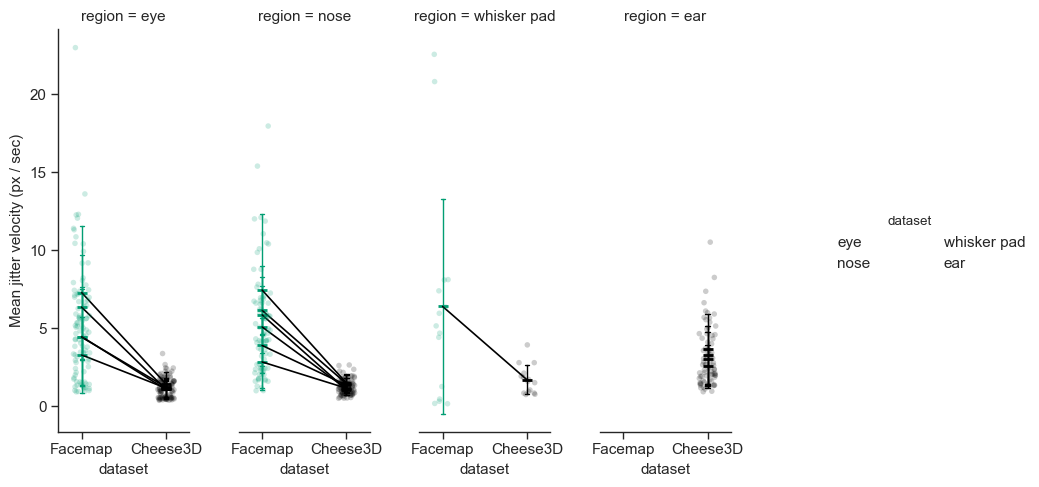

In [21]:
REGION_ORDER_v2 = ["eye", "nose", "whisker pad", "mouth", "ear"]
sub_df = jitter_common_df_2d.dropna(axis=0)
sub_df = sort_by_region(sub_df, REGION_ORDER_v2, "dataset", asc = True)

# sub_df = jitter_common_df_2d.dropna(axis=0)
# REGION_ORDER_v2 = ["eye", "mouth", "whisker pad", "nose", "ear"] #"mouth",
# sub_df = sort_by_region(sub_df, REGION_ORDER_v2, "dataset", col_name = "region_side", asc = False)

def plot_2d_vs_2dproj(dataset, region, view, velocity, color, label):
    xs = dataset.values
    ys = velocity.values
    _region = region.unique()[0]
    all_ys = []
    for d in dataset.unique():
        _ys = ys[xs == d]
        all_ys.append(_ys)
    xs = np.repeat(dataset.unique(), [len(y) for y in all_ys])
    colors = [sns.color_palette("colorblind")[2] if dxs == 'Facemap' else 'black' for dxs in xs]
    ys = np.concatenate(all_ys, axis=0)
    sns.stripplot(x=xs, y=ys,
                #   color=centers_cmap[_region],
                  palette = colors,
                  dodge=True,
                  alpha=0.2,
                  size=4)
    xs = dataset.values
    colors = [sns.color_palette("colorblind")[2] if dxs == 'Facemap' else 'black' for dxs in xs]
    for v in view.unique():
        ys = velocity.values
        ys = ys[view == v]
        xs = np.repeat(dataset.unique(), [len(ys)])
        sns.pointplot(x=xs, y=ys,
                    errorbar=(lambda x: (x.mean() - x.std(ddof=1),
                                        x.mean() + x.std(ddof=1))),
                    capsize=0.05,
                    linewidth=1,
                    marker="_", markersize=7.5, markeredgewidth=2,
                    #   color=centers_cmap[_region],
                    palette = colors,
                    label=label)

g = sns.FacetGrid(sub_df.query("region != 'mouth'"),
                  col="region", hue="dataset",
                  hue_order=['Facemap', 'Post-triangulation 2D'],
                  height = 5,
                  aspect=0.4,
                  sharey=True,
                #   sharex=False,
                  margin_titles=True)
g.map(plot_2d_vs_2dproj, "dataset", "region", "view", "mean_velocity")
# g.add_legend(label_order=list(centers_cmap.keys()), ncols=3)
g.add_legend(label_order=[r for r in REGION_ORDER_v2 if r != 'mouth'], ncols=2)
# # g.figure.suptitle("Coordinate-wise Deviadtion from Mean Landmark Position")
g.set_xticklabels(["Facemap", "Cheese3D"])
g.set_ylabels("Mean jitter velocity (px / sec)")
g.tight_layout(h_pad=0.01, w_pad = 2.5)

regions = REGION_ORDER_v2 #[r for r in REGION_ORDER_v2 if r!= 'mouth']
for col, ax in enumerate(g.axes.flat):
    ax.margins(x=0.15)
    if col < 3:
        r = regions[col]
        for v in set(jitter_common_df_2d.query("dataset == 'Facemap' & region == @r")['view']):
            ys_0 = np.mean(jitter_common_df_2d.query("dataset == 'Post-triangulation 2D' & view == @v & region == @r")['mean_velocity'].values)
            sd_0 = np.std(jitter_common_df_2d.query("dataset == 'Post-triangulation 2D' & view == @v & region == @r")['mean_velocity'].values, ddof=1)
            ys_1 = np.mean(jitter_common_df_2d.query("dataset == 'Facemap' & view == @v & region == @r")['mean_velocity'].values)
            sd_1 = np.std(jitter_common_df_2d.query("dataset == 'Facemap' & view == @v & region == @r")['mean_velocity'].values, ddof=1)
            print(r, v, '\nFacemap: ', ys_1, '+/-', sd_1, '\nCheese3D: ', ys_0, '+/-', sd_0)
            sns.lineplot(x = [1, 0], y = [ys_0, ys_1], color = 'black', ax = ax, legend=False)
    if col > 0:
        sns.despine(ax=ax, left=True)
        ax.tick_params(axis="y", left=False)

# save_figure(OUTPUT_DIR, "a-suppl-keypoint-jitter-summary-2Dreproj-vs-facemap-per-region-Jan29", g.figure)

## 4. Statistics

In [22]:
for v in set(jitter_common_df_2d.query("dataset == 'Post-triangulation 2D' & region == 'ear'")['view']):
    ys_0 = np.mean(jitter_common_df_2d.query("dataset == 'Post-triangulation 2D' & view == @v & region == 'ear'")['mean_velocity'].values)
    sd_0 = np.std(jitter_common_df_2d.query("dataset == 'Post-triangulation 2D' & view == @v & region == 'ear'")['mean_velocity'].values, ddof=1)
    print('Cheese3D ear', v, ys_0, '+/-', sd_0)

Cheese3D ear R 3.251531580241719 +/- 1.9143755806216178
Cheese3D ear TL 3.0444571879095443 +/- 1.7383745482150976
Cheese3D ear L 3.642133924525205 +/- 2.2362776144107146
Cheese3D ear TR 2.5540380411760237 +/- 1.3915123502708528


In [23]:
# for rgn in REGION_ORDER_v2:
#     for v in set(jitter_common_df_2d.query("dataset == 'Post-triangulation 2D' & region == @rgn")['view']):
#         jitter_common_df_2d.query("region == @rgn & view == @v").sort_values(["landmark", "mouse", "dataset"]).to_csv(f'measurements-data-cache/CSVs/{rgn}-{v}-facemap-vs-c3d-jitter-results.csv', index=False)

In [24]:
for rgn in REGION_ORDER_v2:
    if rgn in ['ear', 'mouth']:
        continue
    for v in set(jitter_common_df_2d.query("dataset == 'Facemap' & region == @rgn")['view']):
        print(rgn, v)
        # views = common_v[rgn] if rgn != 'eye' else common_v[f'{rgn}(right)'] + common_v[f'{rgn}(left)'] #Use only the views where the region shows in Facemap and C3D
        fm_mean = jitter_common_df_2d.query("dataset == 'Facemap' & region == @rgn & view == @v")["mean_velocity"].values
        c3d_mean = jitter_common_df_2d.query("dataset == 'Post-triangulation 2D' & region == @rgn & view == @v")["mean_velocity"].values
        # print(list(jitter_df_2d.query("dataset == 'Facemap' & region == @rgn & coordinate == 'vector' & view in @views")["landmark"]) == list(jitter_df_2d.query("dataset == 'Post-triangulation 2D' & region == @rgn & coordinate == 'vector' & view in @views")["landmark"]))
        # print('Facemap', len(fm_mean), 'Cheese3D', len(c3d_mean))
        # print(set(jitter_df_2d.query("dataset == 'Facemap' & region == @rgn & coordinate == 'vector' & view in @views")["landmark"]))
        stat, pval = wilcoxon(fm_mean, c3d_mean, alternative="greater")
        print('p = ', pval)

eye TC
p =  9.5367431640625e-07
eye TR
p =  9.5367431640625e-07
eye TL
p =  1.9073486328125e-06
eye L
p =  9.5367431640625e-07
eye R
p =  9.5367431640625e-07
nose TC
p =  0.0009765625
nose TR
p =  3.0517578125e-05
nose TL
p =  3.0517578125e-05
nose L
p =  3.0517578125e-05
nose BC
p =  3.0517578125e-05
nose R
p =  3.0517578125e-05
whisker pad R
p =  0.002685546875
